In [ ]:
from sklearn.model_selection import cross_validate

In [ ]:
# выделяем интересующие нас факторы
X = boston_data[['LSTAT', 'PTRATIO', 'RM','CRIM']]
y = boston_data[['PRICE']]
 
# добавляем полиномиальные признаки
poly = PolynomialFeatures(degree=3, include_bias=False)
X = poly.fit_transform(X)
 
# создаём модель линейной регрессии
lr = LinearRegression()
 
# оцениваем качество модели на кросс-валидации, метрика — MAPE
cv_results = cross_validate(lr, X, y, scoring='neg_mean_absolute_percentage_error', cv=5, return_train_score=True)
print('MAPE на тренировочных фолдах: {:.2f} %'.format(-cv_results['train_score'].mean()* 100))
print('MAPE на валидационных фолдах: {:.2f} %'.format(-cv_results['test_score'].mean() * 100))	
 
## MAPE на тренировочных фолдах: 12.64 %
## MAPE на валидационных фолдах: 24.16 %

In [ ]:
# выделяем интересующие нас факторы
X = boston_data[['LSTAT', 'PTRATIO', 'RM','CRIM']]
y = boston_data[['PRICE']]
# инициализируем стандартизатор StandardScaler
scaler = StandardScaler()
# подгоняем параметры стандартизатора (вычисляем среднее и СКО)
X = scaler.fit_transform(X)
# добавляем полиномиальные признаки
poly = PolynomialFeatures(degree=3, include_bias=False)
X = poly.fit_transform(X)
# создаём модель линейной регрессии c L2-регуляризацией
ridge = Ridge(alpha=20, solver='svd')
# оцениваем качество модели на кросс-валидации
cv_results = cross_validate(ridge, X, y, scoring='neg_mean_absolute_percentage_error', cv=5, return_train_score=True)
print('MAPE на тренировочных фолдах: {:.2f} %'.format(-cv_results['train_score'].mean()* 100))
print('MAPE на валидационных фолдах: {:.2f} %'.format(-cv_results['test_score'].mean() * 100))
## MAPE на тренировочных фолдах: 12.54 %
## MAPE на валидационных фолдах: 17.02 %

In [1]:
import numpy as np
A = np.array([
    [1, 1, 1, 1, 1],
    [5, 9, 4, 3, 5],
    [15, 18, 18, 19, 19],
    [7, 6, 7, 7, 7]
]).T
y = np.array([24, 22, 35, 33, 36])
E = np.eye(4)
# коэффициент регуляризации
alpha = 1
# получаем оценку коэффициентов регрессии по МНК с регуляризацией Тихонова
w_hat_ridge = np.linalg.inv(A.T@A+alpha*E)@A.T@y
print(np.round(w_hat_ridge, 2))

[-0.09 -1.71  1.91  0.73]


In [ ]:
# выделяем интересующие нас факторы
X = boston_data[['LSTAT', 'PTRATIO', 'RM','CRIM']]
y = boston_data[['PRICE']]
# инициализируем стандартизатор StandardScaler
scaler = StandardScaler()
# подгоняем параметры стандартизатора (вычисляем среднее и СКО)
X = scaler.fit_transform(X)
# добавляем полиномиальные признаки
poly = PolynomialFeatures(degree=3, include_bias=False)
X = poly.fit_transform(X)
# создаём модель линейной регрессии c L1- и L2-регуляризациями
lasso = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
# оцениваем качество модели на кросс-валидации
cv_results = cross_validate(lasso, X, y, scoring='neg_mean_absolute_percentage_error', cv=5, return_train_score=True)
print('MAPE на тренировочных фолдах: {:.2f} %'.format(-cv_results['train_score'].mean()* 100))
print('MAPE на валидационных фолдах: {:.2f} %'.format(-cv_results['test_score'].mean() * 100)) 
## MAPE на тренировочных фолдах: 12.65 %
## MAPE на валидационных фолдах: 15.70 %

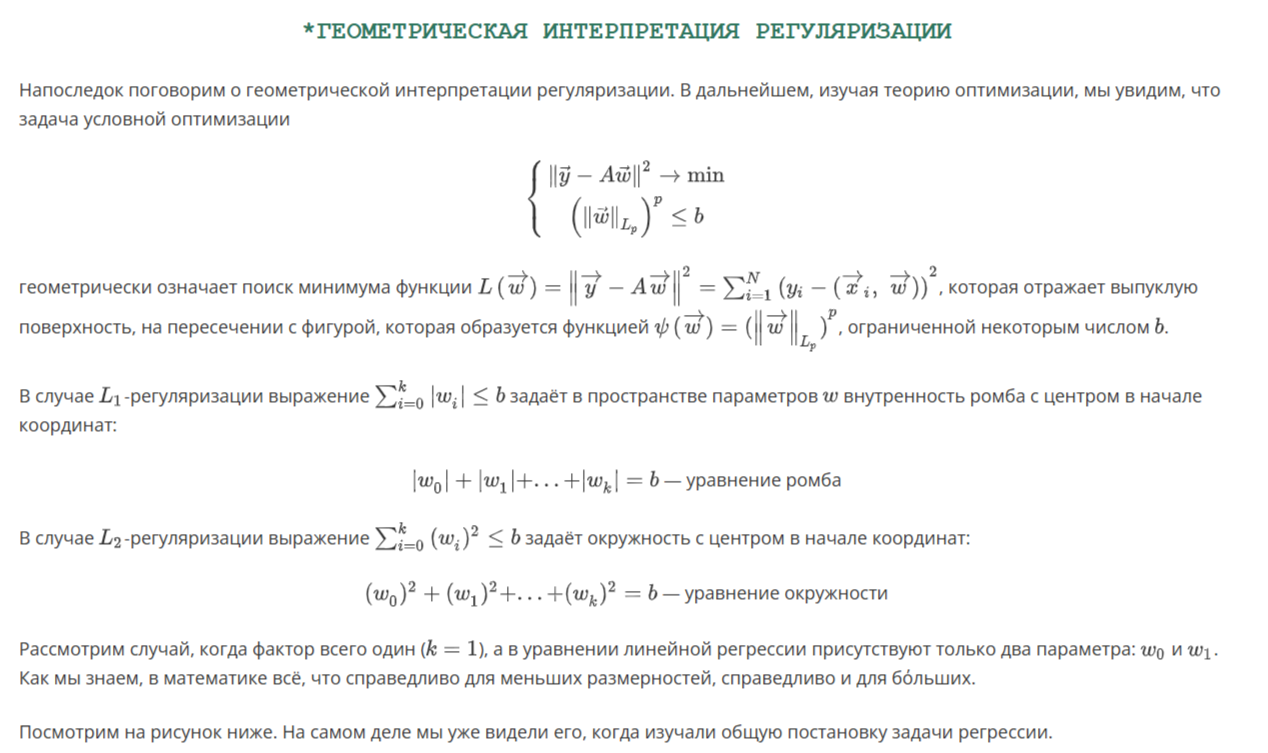

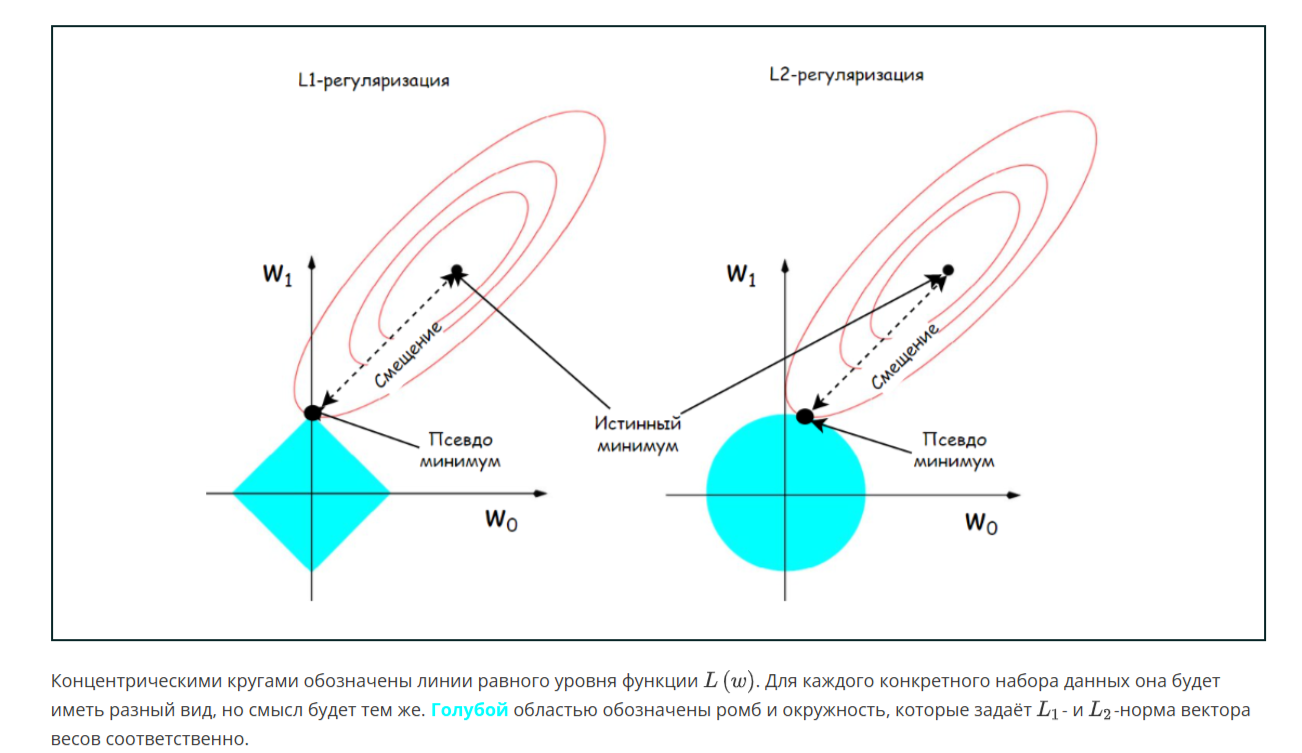

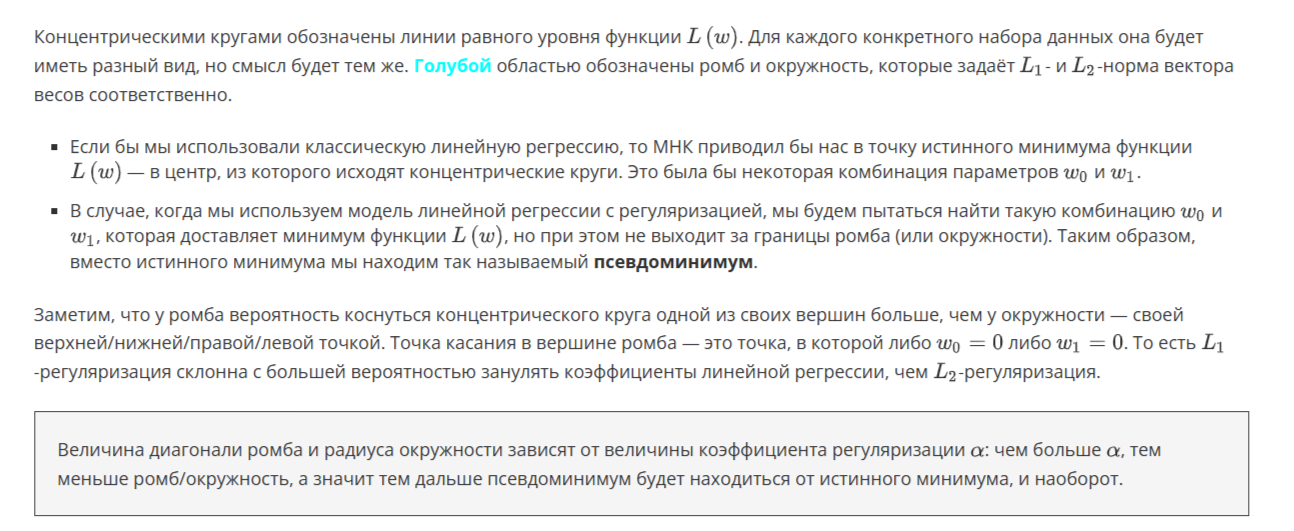

In [2]:
# создаем матрицу А
import numpy as np
A = np.array([
    [3, 1],
    [2, 2]
]).T
# вычисляем собственные числа и собственные векторы
eig_values, eig_vectors = np.linalg.eig(A)
print('Собственные числа: \n', eig_values)
print('Собственные векторы: \n', eig_vectors)

Собственные числа: 
 [4. 1.]
Собственные векторы: 
 [[ 0.89442719 -0.70710678]
 [ 0.4472136   0.70710678]]


In [3]:
# создаем матрицу А
A = np.array([
    [1, -5, -6],
    [4, 8, 7],
    [5, 9, 11]
]).T
# вычисляем собственные числа и собственные векторы
eig_values, eig_vectors = np.linalg.eig(A)
print('Собственные числа: \n', eig_values)
print('Собственные векторы: \n', eig_vectors)

Собственные числа: 
 [13.59373746  5.03209301  1.37416954]
Собственные векторы: 
 [[ 0.45145779  0.83661458  0.10258363]
 [ 0.62348353  0.44632316 -0.77299039]
 [ 0.63832135  0.31760303  0.62606905]]


In [4]:
# создаем матрицу А
A = np.array([
    [1, -4, -5, -6],
    [4, 12, 8, 7],
    [5, 14, 9, 11],    [8, 15, 7, 4]
]).T
# вычисляем собственные числа и собственные векторы
eig_values, eig_vectors = np.linalg.eig(A)
print('Собственные числа: \n', eig_values)
print('Собственные векторы: \n', eig_vectors)

Собственные числа: 
 [ 2.54687092e+01  1.53129080e+00  1.63252001e-14 -1.00000000e+00]
Собственные векторы: 
 [[-0.33176532 -0.6739195   0.5479715  -0.5312532 ]
 [-0.75622544 -0.67703635  0.72006173 -0.64930947]
 [-0.42446012 -0.00311685 -0.00452869 -0.11805627]
 [-0.37133334  0.2957103  -0.42569687  0.5312532 ]]


In [5]:
# создаем матрицу А
A = np.array([
    [0, 1],
    [-1, 0],
]).T
# вычисляем собственные числа и собственные векторы
eig_values, eig_vectors = np.linalg.eig(A)
print('Собственные числа: \n', eig_values)
print('Собственные векторы: \n', eig_vectors)

Собственные числа: 
 [0.+1.j 0.-1.j]
Собственные векторы: 
 [[0.70710678+0.j         0.70710678-0.j        ]
 [0.        -0.70710678j 0.        +0.70710678j]]


In [8]:
# создаем матрицу А
A = np.array([
    [1, 9, 4],
    [9, 4, 7],
    [4, 7, 12]
]).T
# вычисляем собственные числа и собственные векторы
eig_values, eig_vectors = np.linalg.eig(A@A.T)
print('Собственные числа: \n', np.round(eig_values))
print('Собственные векторы: \n', np.round(eig_vectors))

Собственные числа: 
 [391.  46.  16.]
Собственные векторы: 
 [[-0. -1. -1.]
 [-1.  1. -0.]
 [-1. -0.  1.]]


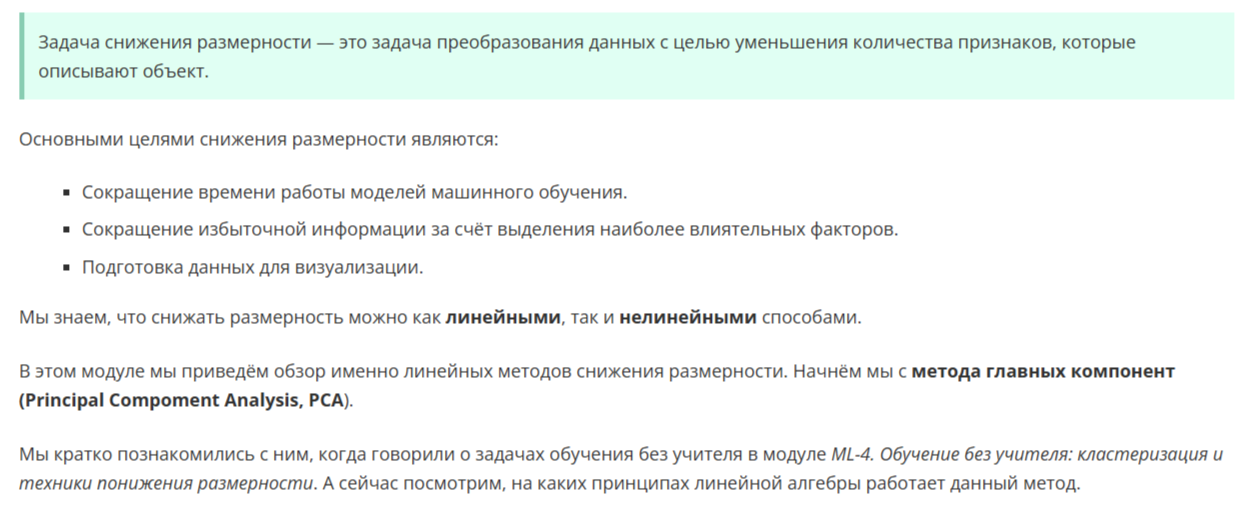

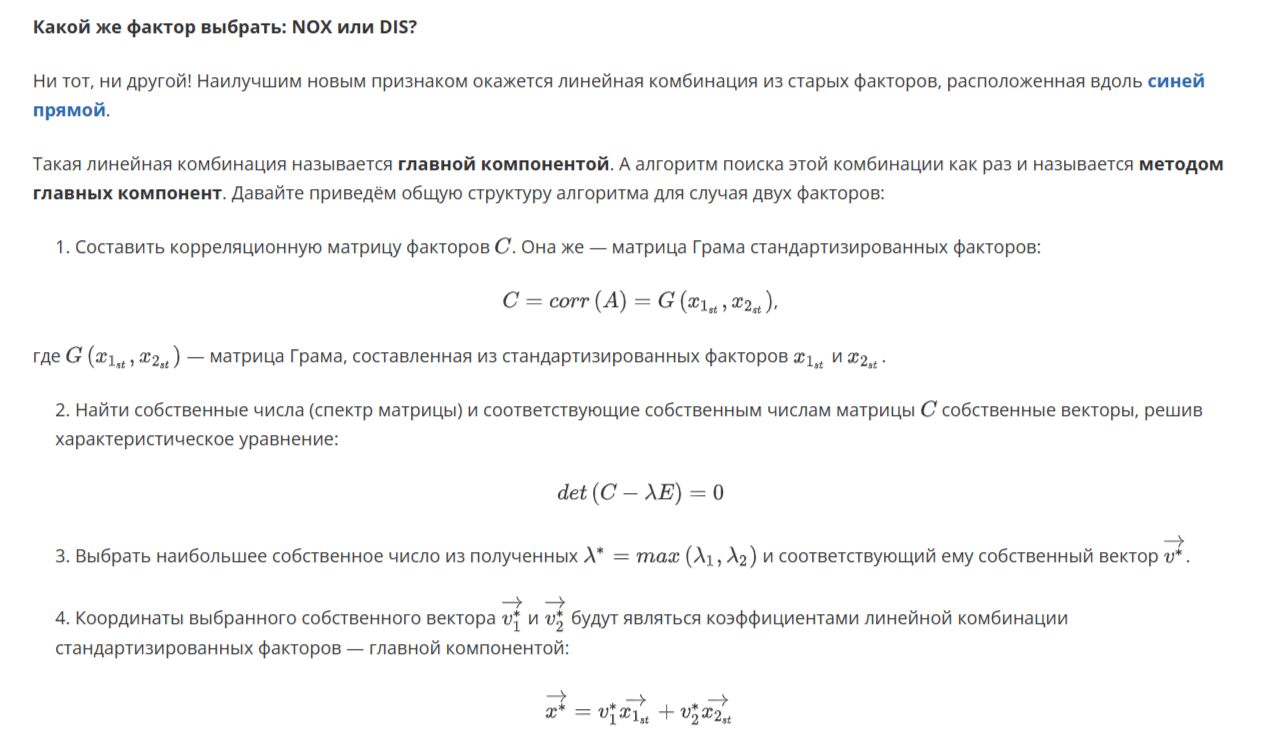

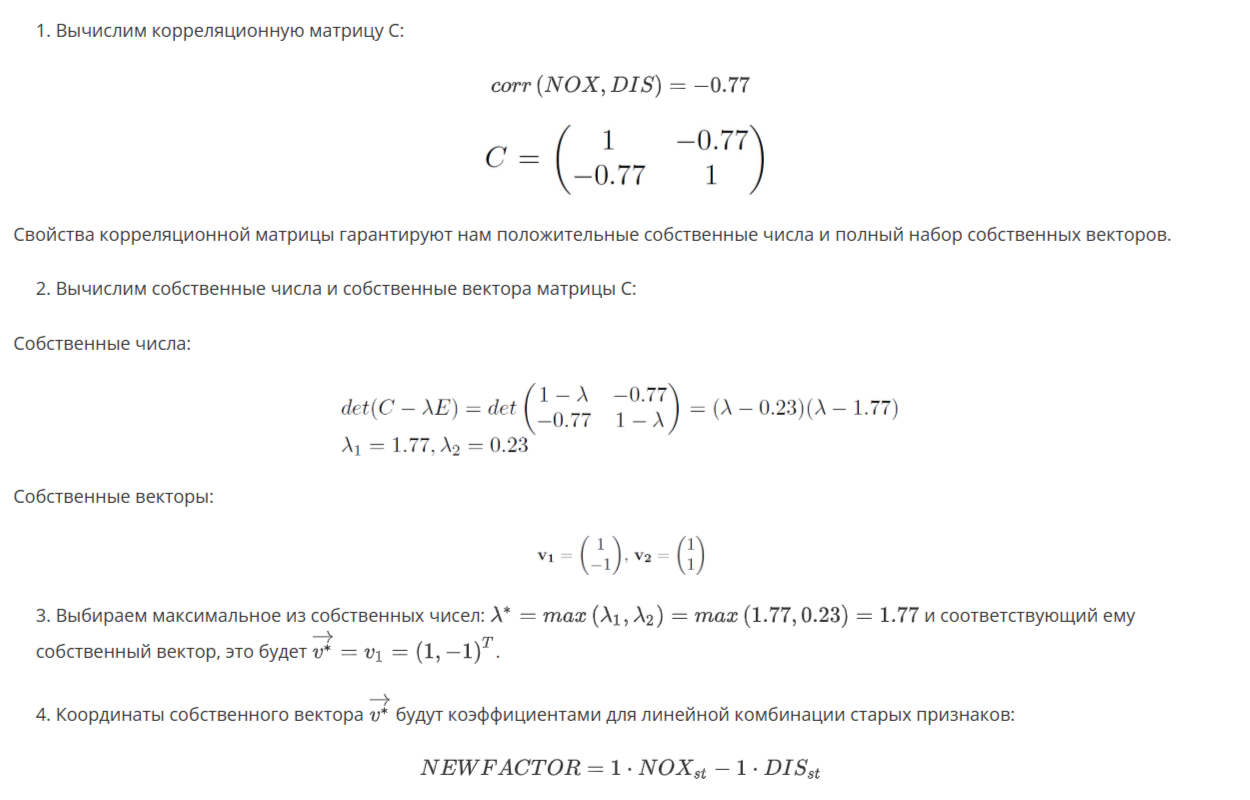

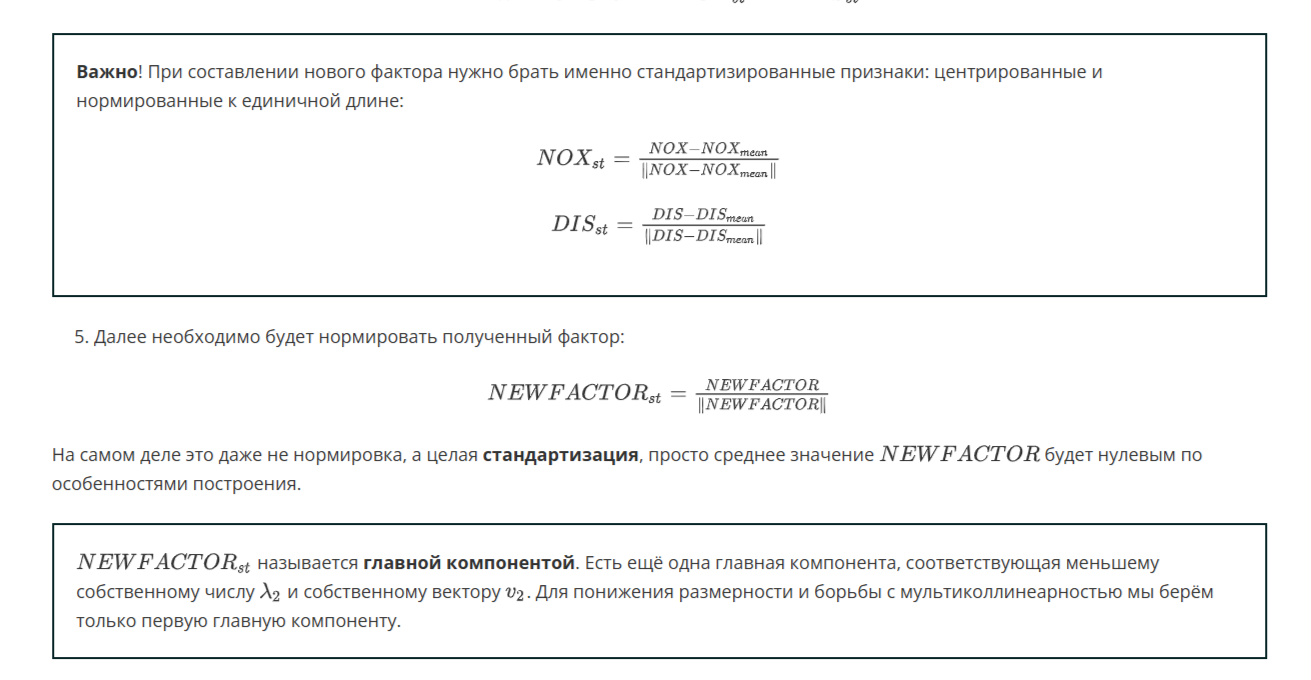

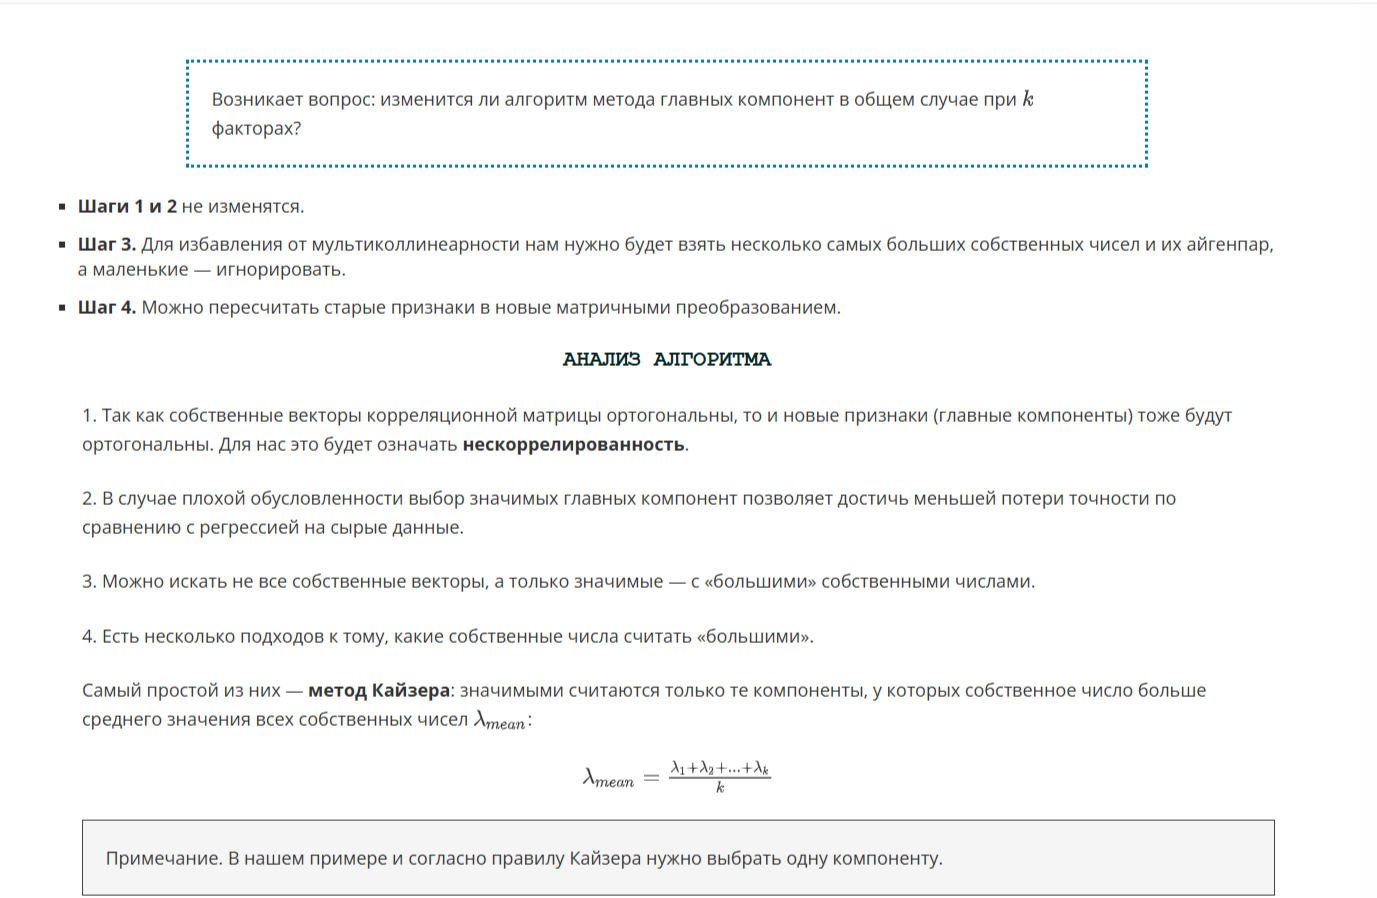

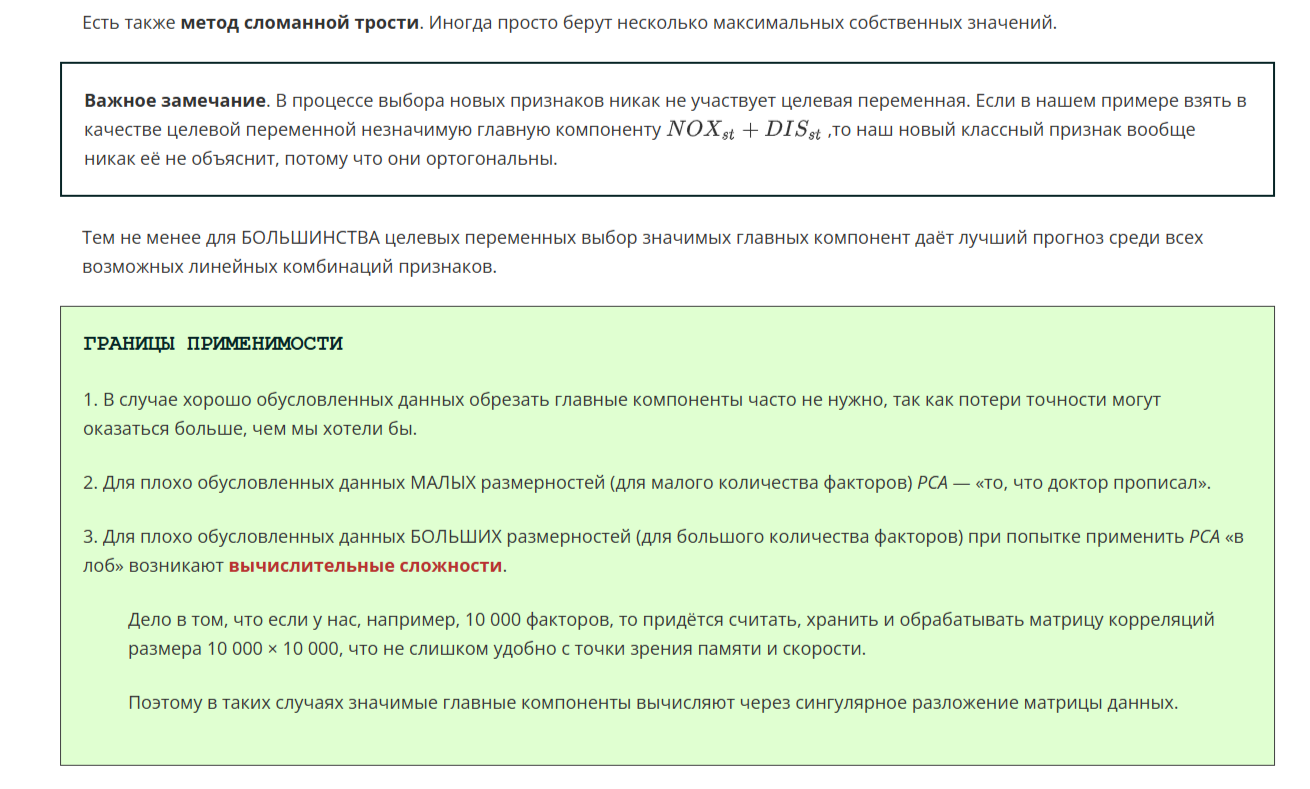